In [1]:
# -*- coding: utf-8 -*-
from __future__ import division
#import matplotlib
from pylab import *

# from numpy import linalg as LA
import torch
from tqdm import tqdm
import pickle

np.set_printoptions(threshold=np.inf)

torch.set_printoptions(profile="full")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [46]:
K=float(4)

# K_list = np.arange(0, 4 + 0.1, 0.1)

# K_list = [0.001, 0.01, 0.1, 1, 3, 5, 7]

Cs = []
N=200	#100
# N_list = [10, 20, 50, 100, 200, 400, 1000]

# many_dicts = []

#-----------N list------------------
# for i in range(len(N_list)):
# 	dict_all = fire(N_list[i], K)
# 	many_dicts.append(dict_all)

#------------K list------------------
# for i in tqdm(range(K_list.shape[0])):
    # k = K_list[i]

#     C = []
#     for i in range(1000):
#         last_fire = fire_static(N, k)
#         C.append(last_fire)
#     Cs.append(sum(C)/len(C))

# print(Cs)

#-----------single run---------------
fire_data = []
Lamb_dyn = []
connectivity = []

neuron_v=torch.zeros(N, device=device)
neuron_v_new=torch.zeros(N, device=device)
neuron_history=torch.zeros(N, device=device)
weights=torch.rand((N,N), device=device)
# weights=(torch.rand((N,N), device=device) > 0.5).float()
weights.fill_diagonal_(0)

ind=np.random.choice(range(N), int(N*0.2), replace=False)
weights[:,ind]=weights[:,ind]*-1

sum_weights=torch.sum(weights)
weights=weights/sum_weights*N*K

initial_c = weights.mean().cpu()

In [52]:
initial_c

tensor(0.0200)

In [ ]:
# one initial activity run
neuron_v=torch.zeros(N, device=device)
idx = torch.randint(0, N, (1,), device=device).item()
print(idx)
neuron_v[idx]=1 	# background activity original, without Rate in filename
t=0

# coverge loop
while neuron_v.sum()>0 and t<50:
    prob_spiking=torch.matmul(weights, neuron_v)
    rand_vals = torch.rand_like(prob_spiking)

    spike_mask = (prob_spiking >= 1) | (
        (prob_spiking > 0) & 
        (prob_spiking < 1) &
        (rand_vals < prob_spiking)
    )

    neuron_v_new[spike_mask] = 1
    neuron_history[spike_mask] = 1

    ### Shew 2015
    #prob_spiking=0
    #for j in range(N):
    #	if i!=j:
    #		prob_spiking=prob_spiking + (weights[i,j]*neuron_v[j])


    fire_data.append(neuron_v_new.detach().cpu().clone())
    
    neuron_v[:]=neuron_v_new[:]
    neuron_v_new[:]=0
    #neuron_v[random.randint(0,N-1)]=1 	# background activity original, without Rate in filename
    t=t+1

51


In [5]:
fire_data = np.array(fire_data)

In [ ]:
fire_data.shape

In [7]:
fire_sum = np.sum(fire_data, axis=1)

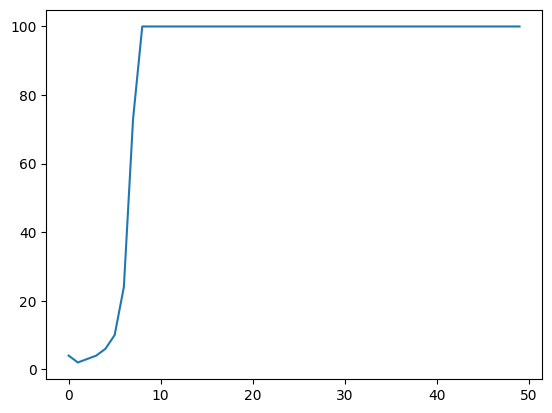

In [8]:
plt.plot(fire_sum)

In [47]:
# weight update loop
for born in tqdm(range(100)):
    neuron_history=torch.zeros(N, device=device)

    # run loop with random activities
    for run in range(100):
        ### start avalanche
        neuron_v=torch.zeros(N, device=device)
        idx = torch.randint(0, N, (1,), device=device).item()
        # print(idx)
        neuron_v[idx]=1 	# background activity original, without Rate in filename
        t=0

        # coverge loop
        while neuron_v.sum()>0 and t<50:
            prob_spiking=torch.matmul(weights, neuron_v)
            rand_vals = torch.rand_like(prob_spiking)

            spike_mask = (prob_spiking >= 1) | (
                (prob_spiking > 0) & 
                (prob_spiking < 1) &
                (rand_vals < prob_spiking)
            )

            neuron_v_new[spike_mask] = 1
            neuron_history[spike_mask] = 1

            ### Shew 2015
            #prob_spiking=0
            #for j in range(N):
            #	if i!=j:
            #		prob_spiking=prob_spiking + (weights[i,j]*neuron_v[j])

        
            fire_data.append(neuron_v_new.detach().cpu().clone())
            
            neuron_v[:]=neuron_v_new[:]
            neuron_v_new[:]=0
            #neuron_v[random.randint(0,N-1)]=1 	# background activity original, without Rate in filename
            t=t+1
        fire_data.append(torch.full((100,), 2))

    # rewiring
    for _ in range(20):
        rand_neuron=torch.randint(0, N, (1,), device=device).item()
        rand_incoming=torch.randint(0, N, (1,), device=device).item()
        while rand_neuron==rand_incoming:
            rand_incoming=torch.randint(0, N, (1,), device=device).item()
        if neuron_history[rand_neuron]==0:
            #if weights[rand_neuron,rand_incoming]<=0.9:
                weights[rand_neuron,rand_incoming]=torch.rand((), device=device)#weights[rand_neuron,rand_incoming]+0.1#
        if neuron_history[rand_neuron]==1:
                weights[rand_neuron,rand_incoming]=0#weights[rand_neuron,rand_incoming]-0.1#
                if weights[rand_neuron,rand_incoming]<0:
                    weights[rand_neuron,rand_incoming]=0
        sum_weights=torch.sum(weights)
        weights=weights/sum_weights*N*K
    
    if born % 200 == 0:
        w = torch.linalg.eigvals(weights)
        Lamb_dyn.append(w.abs().max().item())
    connectivity.append(weights.mean().cpu())


dict_all = {
    'lamb': Lamb_dyn,
    'connectivity': connectivity,
    'fire_data': fire_data,
    'initial_connectivity': initial_c
}


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:40<00:00,  2.46it/s]


In [48]:
connectivity = np.array(connectivity)

In [51]:
connectivity

array([0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02,
       0.02], dtype=float32)

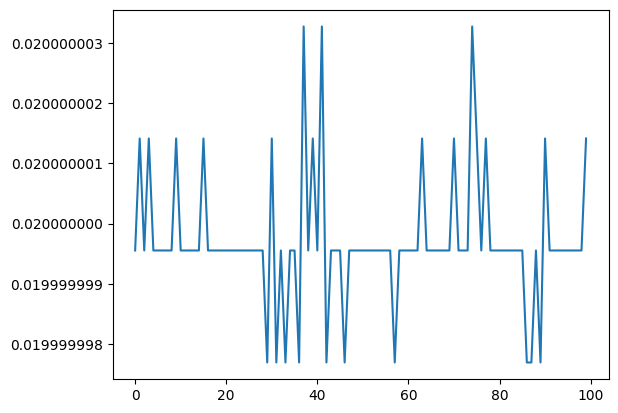

In [55]:

plt.ticklabel_format(axis='y', style='plain', useOffset=False)
plt.plot(connectivity)

In [43]:
fire_data = np.array(fire_data)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (40062,) + inhomogeneous part.

In [48]:
fire_data.shape

(3138, 100)

In [49]:
fire_sum = np.sum(fire_data, axis=1)

In [50]:
restart_idx = np.where(fire_sum == 200)[0]

In [54]:
num = 0
for i in restart_idx:
    if fire_sum[i-1] == 0:
        num+=1
print(num)

274


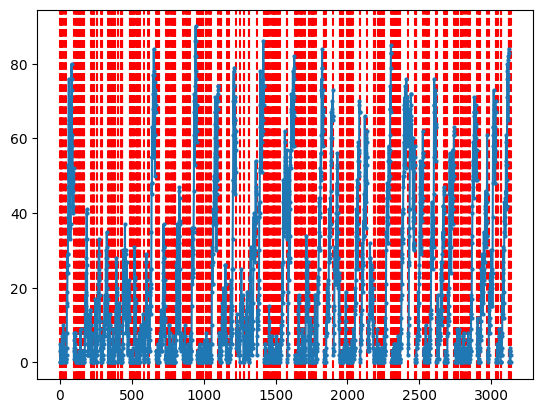

In [53]:
y_plot = fire_sum[:].copy()
restart_idx = np.where(y_plot == 200)[0]
y_plot[restart_idx] = np.nan
for i in restart_idx:
    plt.axvline(x = i, color='red', linestyle='--')
plt.plot(y_plot, marker="o", markersize=2)

Error in callback <function _draw_all_if_interactive at 0x11924dbc0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

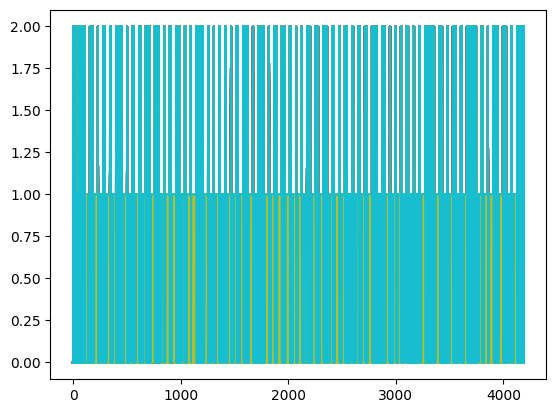

In [21]:
plt.plot(fire_data)

In [5]:
dict_all

{'lamb': [0.9759847521781921],
 'connectivity': [tensor(0.0100),
  tensor(0.0103),
  tensor(0.0103),
  tensor(0.0104),
  tensor(0.0104),
  tensor(0.0104),
  tensor(0.0104),
  tensor(0.0105),
  tensor(0.0105),
  tensor(0.0110),
  tensor(0.0110),
  tensor(0.0110),
  tensor(0.0114),
  tensor(0.0114),
  tensor(0.0113),
  tensor(0.0113),
  tensor(0.0113),
  tensor(0.0113),
  tensor(0.0113),
  tensor(0.0113),
  tensor(0.0112),
  tensor(0.0112),
  tensor(0.0112),
  tensor(0.0112),
  tensor(0.0117),
  tensor(0.0117),
  tensor(0.0117),
  tensor(0.0117),
  tensor(0.0117),
  tensor(0.0117)],
 'fire_data': [tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,